<a href="https://colab.research.google.com/github/JuliMiralles/Diplomatura-en-An-lisis-Cuantitativo-y-Machine-Learning-aplicado-al-Riesgo-Financiero/blob/main/Modulo1_Clase3_VaR_ES_Backtesting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Módulo 1 · Clase 3 — Medición de la exposición
## VaR, Expected Shortfall, backtesting y stress testing

Diplomatura en Análisis Cuantitativo y Machine Learning aplicado al Riesgo Financiero  
**Universidad Austral — Sede Rosario**  
Dr. Rodrigo Del Rosso — Director Académico

---

Este notebook parte del panel de retornos construido en la Clase 2 y calcula, sobre la
misma cartera de **10 millones de dólares**, el VaR y el Expected Shortfall por cuatro
métodos, valida los modelos con backtesting formal y aplica escenarios de estrés.

| Bloque | Contenido |
|---|---|
| 1 | Los cuatro estimadores de VaR y ES |
| 2 | Comparación y descomposición por posición |
| 3 | Backtesting: Kupiec, Christoffersen y semáforo de Basilea |
| 4 | Stress testing y límites del modelo |
| 5 | Informe de riesgo asistido por IA |


## Bloque 0 · Configuración y datos

In [ ]:
# Configuración del entorno
!pip -q install yfinance arch statsmodels --upgrade

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

SEMILLA = 20260901
rng = np.random.default_rng(SEMILLA)

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({
    "figure.figsize": (11, 3.4), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

# Paleta institucional (tomada de la identidad visual de la Universidad Austral)
AZUL, CELESTE, NARANJA, VINO = "#1A25AB", "#67A0D5", "#EB7D0C", "#771C2D"
ROJO, GRIS = "#C41230", "#9A9A9A"
COLORES = {"SPY": AZUL, "TLT": CELESTE, "GLD": NARANJA, "EURUSD": VINO}

import sys
print("Python", sys.version.split()[0], "| numpy", np.__version__, "| pandas", pd.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.3/149.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 982.9/982.9 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 3.7 MB/s eta 0:00:00
Python 3.13.15 | numpy 2.1.3 | pandas 2.2.3


In [ ]:
import yfinance as yf

TICKERS = ["SPY", "TLT", "GLD", "EURUSD=X"]
NOMBRES = ["SPY", "TLT", "GLD", "EURUSD"]
INICIO, FIN = "2021-03-01", "2026-03-01"

raw = yf.download(TICKERS, start=INICIO, end=FIN, auto_adjust=True, progress=False)["Close"]
raw = raw[TICKERS]
raw.columns = NOMBRES

print("Filas descargadas:", len(raw))
print("Faltantes por columna:\n", raw.isna().sum(), sep="")

# Intersección de calendarios: se descarta la fecha si falta algún instrumento.
# Alternativa (NO recomendada): raw.ffill(), que imputa retornos nulos.
px = raw.dropna(how="any").copy()
print(f"\nFechas conservadas: {len(px)} de {len(raw)} ({len(px)/len(raw):.1%})")
px.tail()

Filas descargadas: 1301
Faltantes por columna:
SPY       45
TLT       45
GLD       45
EURUSD     1
dtype: int64

Fechas conservadas: 1255 de 1301 (96.5%)


,SPY,TLT,GLD,EURUSD
Date,,,,
2026-02-23,678.7828,87.3975,481.2800,1.1835
2026-02-24,683.7165,87.5533,474.6100,1.1794
2026-02-25,689.4859,87.5630,473.4200,1.1775
2026-02-26,685.6562,87.9136,477.4800,1.1815
2026-02-27,682.3637,88.4493,483.7500,1.1803


In [ ]:
ret = np.log(px / px.shift(1)).dropna()

# ---- Control 2 · dimensional y de rango -------------------------------------
assert ret.notna().all().all(), "Hay valores faltantes en los retornos"
extremos = (ret.abs() > 0.25).sum()
print("Retornos con |r| > 25 % (revisar uno por uno si son > 0):\n", extremos, sep="")

huecos = ret.index.to_series().diff().dt.days.max()
print(f"\nHueco máximo en el índice: {huecos:.0f} días corridos")
print(f"Período: {ret.index.min():%Y-%m-%d} a {ret.index.max():%Y-%m-%d}  ({len(ret)} ruedas)")

ret.describe().T[["mean", "std", "min", "max"]]

Retornos con |r| > 25 % (revisar uno por uno si son > 0):
SPY       0
TLT       0
GLD       0
EURUSD    0
dtype: int64

Hueco máximo en el índice: 5 días corridos
Período: 2021-03-02 a 2026-02-27  (1254 ruedas)


,mean,std,min,max
SPY,0.0005,0.0106,-0.0603,0.0999
TLT,-0.0002,0.0100,-0.0348,0.0378
GLD,0.0009,0.0108,-0.1084,0.0616
EURUSD,-0.0000,0.0048,-0.0186,0.0275


In [ ]:
PESOS = pd.Series({"SPY": 0.40, "TLT": 0.30, "GLD": 0.20, "EURUSD": 0.10})
w  = PESOS.values
V0 = 10_000_000.0
ALPHA_VAR, ALPHA_ES = 0.99, 0.975

rp   = ret @ w                 # retorno diario de la cartera
pnl  = V0 * rp                 # resultado en USD
loss = -pnl                    # CONVENCION: perdida positiva
n    = len(loss)

mu_L, sd_L = loss.mean(), loss.std(ddof=1)
print(f"Ruedas                        : {n}")
print(f"Media de la pérdida diaria    : {mu_L:>12,.0f} USD")
print(f"Desvío de la pérdida diaria   : {sd_L:>12,.0f} USD")
print(f"Volatilidad anualizada        : {rp.std(ddof=1)*np.sqrt(252):>12.2%}")

Ruedas                        : 1254
Media de la pérdida diaria    :       -3,079 USD
Desvío de la pérdida diaria   :       62,387 USD
Volatilidad anualizada        :        9.90%


## Bloque 1 · Los cuatro estimadores

$$\mathrm{VaR}_\alpha(L)=\inf\{\ell:\ \mathbb{P}(L>\ell)\le 1-\alpha\},\qquad
\mathrm{ES}_\alpha(L)=\mathbb{E}\left[L \mid L>\mathrm{VaR}_\alpha(L)\right]$$

### 1.1 Paramétrico (normal y t de Student)

In [ ]:
def var_es_normal(L, a_var=ALPHA_VAR, a_es=ALPHA_ES):
    m, s = L.mean(), L.std(ddof=1)
    var = m + s * stats.norm.ppf(a_var)
    es  = m + s * stats.norm.pdf(stats.norm.ppf(a_es)) / (1 - a_es)
    return var, es

def var_es_t(L, a_var=ALPHA_VAR, a_es=ALPHA_ES):
    nu, loc, sc = stats.t.fit(L)
    var = loc + sc * stats.t.ppf(a_var, nu)
    q   = stats.t.ppf(a_es, nu)
    es  = loc + sc * (stats.t.pdf(q, nu) / (1 - a_es)) * ((nu + q ** 2) / (nu - 1))
    return var, es, nu

var_n, es_n = var_es_normal(loss)
var_t, es_t, NU = var_es_t(loss)

print(f"Normal    → VaR 99 % = {var_n:>10,.0f}   ES 97,5 % = {es_n:>10,.0f}")
print(f"t Student → VaR 99 % = {var_t:>10,.0f}   ES 97,5 % = {es_t:>10,.0f}   (ν = {NU:.2f})")
print("\nObservación: bajo normalidad, ES 97,5 % ≈ VaR 99 %.")
print("Esa equivalencia es la que justificó la calibración del marco FRTB.")

Normal    → VaR 99 % =    142,054   ES 97,5 % =    142,769
t Student → VaR 99 % =    156,021   ES 97,5 % =    162,878   (ν = 5.31)

Observación: bajo normalidad, ES 97,5 % ≈ VaR 99 %.
Esa equivalencia es la que justificó la calibración del marco FRTB.


### 1.2 Simulación histórica

In [ ]:
def var_es_hist(L, a_var=ALPHA_VAR, a_es=ALPHA_ES):
    var = np.quantile(L, a_var)
    cola = L[L > np.quantile(L, a_es)]
    return var, cola.mean()

var_h, es_h = var_es_hist(loss)
print(f"Histórico → VaR 99 % = {var_h:>10,.0f}   ES 97,5 % = {es_h:>10,.0f}")
print(f"\nEl VaR al 99 % se apoya en {int(n*0.01)} observaciones de {n}.")
print("Cuanto más extremo el cuantil, más inestable el estimador.")

Histórico → VaR 99 % =    149,255   ES 97,5 % =    164,767

El VaR al 99 % se apoya en 12 observaciones de 1254.
Cuanto más extremo el cuantil, más inestable el estimador.


### 1.3 Simulación de Monte Carlo

Monte Carlo → VaR 99 % =    156,109   ES 97,5 % =    161,224


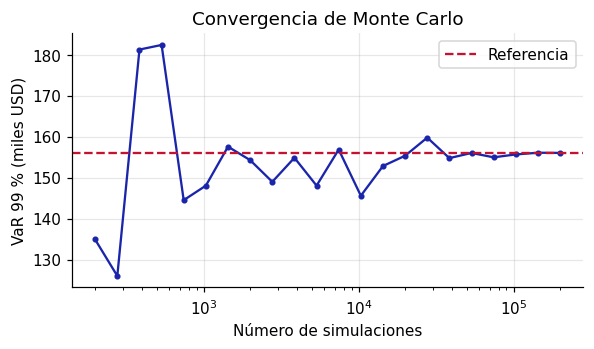

In [ ]:
def var_es_mc(ret, w, V0, m=200_000, nu=6, a_var=ALPHA_VAR, a_es=ALPHA_ES, seed=11):
    """t multivariada: normal escalada por una chi-cuadrado, estandarizada."""
    g = np.random.default_rng(seed)
    S = ret.cov().values
    Lc = np.linalg.cholesky(S)
    z  = g.standard_normal((m, S.shape[0])) @ Lc.T
    u  = g.chisquare(nu, size=(m, 1)) / nu
    sim = ret.mean().values + (z / np.sqrt(u)) / np.sqrt(nu / (nu - 2))
    L = -V0 * (sim @ w)
    return np.quantile(L, a_var), L[L > np.quantile(L, a_es)].mean(), L

var_mc, es_mc, L_mc = var_es_mc(ret, w, V0)
print(f"Monte Carlo → VaR 99 % = {var_mc:>10,.0f}   ES 97,5 % = {es_mc:>10,.0f}")

# ---- Error de simulacion: convergencia -------------------------------------
tam = np.unique(np.logspace(2.3, 5.3, 22).astype(int))
est = [np.quantile(rng.choice(L_mc, t, replace=False), ALPHA_VAR) for t in tam]

fig, ax = plt.subplots(figsize=(6, 3.0))
ax.plot(tam, np.array(est) / 1e3, "o-", color=AZUL, ms=3)
ax.axhline(var_mc / 1e3, color=ROJO, ls="--", label="Referencia")
ax.set_xscale("log"); ax.set_xlabel("Número de simulaciones")
ax.set_ylabel("VaR 99 % (miles USD)"); ax.set_title("Convergencia de Monte Carlo")
ax.legend(); plt.show()

### 1.4 Simulación histórica filtrada

$$z_t=\frac{r_{p,t}}{\sigma_t},\qquad
\mathrm{VaR}_{\alpha,t+1}=-V_t\,\sigma_{t+1}\,\hat q_{1-\alpha}\!\left(\{z_s\}_{s\le t}\right)$$

Combina la reactividad de la volatilidad condicional con la forma de cola observada.

In [ ]:
def ewma_sigma(r, lam=0.94):
    x = np.asarray(r, dtype=float)
    s2 = np.empty(len(x)); s2[0] = x.var(ddof=1)
    for t in range(1, len(x)):
        s2[t] = lam * s2[t - 1] + (1 - lam) * x[t - 1] ** 2
    return np.sqrt(s2)

def var_fhs(rp, V0, a=ALPHA_VAR, lam=0.94, warm=250):
    sig = ewma_sigma(rp, lam)
    z = np.asarray(rp) / sig
    out = np.full(len(rp), np.nan)
    for t in range(warm, len(rp)):
        out[t] = -V0 * sig[t] * np.quantile(z[:t], 1 - a)
    return pd.Series(out, index=rp.index)

VAR_FHS = var_fhs(rp, V0)
print(f"Histórico filtrado → VaR 99 % (último día) = {VAR_FHS.iloc[-1]:,.0f}")
print(f"                     media del período      = {VAR_FHS.mean():,.0f}")

Histórico filtrado → VaR 99 % (último día) = 169,372
                     media del período      = 165,331


## Bloque 2 · Comparación y descomposición

,VaR 99 %,"ES 97,5 %",ES / VaR
Paramétrico normal,"142,054","142,769",1.01
Paramétrico t,"156,021","162,878",1.04
Histórico,"149,255","164,767",1.10
Monte Carlo,"156,109","161,224",1.03


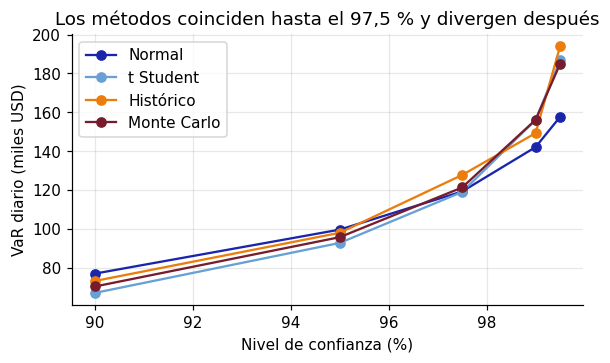

In [ ]:
comp = pd.DataFrame({
    "VaR 99 %":  [var_n, var_t, var_h, var_mc],
    "ES 97,5 %": [es_n, es_t, es_h, es_mc],
}, index=["Paramétrico normal", "Paramétrico t", "Histórico", "Monte Carlo"])
comp["ES / VaR"] = comp["ES 97,5 %"] / comp["VaR 99 %"]
display(comp.style.format({"VaR 99 %": "{:,.0f}", "ES 97,5 %": "{:,.0f}", "ES / VaR": "{:.2f}"}))

niveles = [0.90, 0.95, 0.975, 0.99, 0.995]
curvas = pd.DataFrame({
    "Normal":      [var_es_normal(loss, a, a)[0] for a in niveles],
    "t Student":   [var_es_t(loss, a, 0.975)[0] for a in niveles],
    "Histórico":   [np.quantile(loss, a) for a in niveles],
    "Monte Carlo": [np.quantile(L_mc, a) for a in niveles],
}, index=[f"{a:.1%}" for a in niveles])

fig, ax = plt.subplots(figsize=(6, 3.2))
for col, c in zip(curvas.columns, [AZUL, CELESTE, NARANJA, VINO]):
    ax.plot([a * 100 for a in niveles], curvas[col] / 1e3, "o-", color=c, label=col)
ax.set_xlabel("Nivel de confianza (%)"); ax.set_ylabel("VaR diario (miles USD)")
ax.set_title("Los métodos coinciden hasta el 97,5 % y divergen después")
ax.legend(); plt.show()

### 2.2 VaR componente

$$\mathrm{VaR}_\alpha=\sum_i \mathrm{CVaR}_i,\qquad
\mathrm{CVaR}_i=w_i\,\frac{(\boldsymbol{\Sigma}\mathbf{w})_i}{\sigma_p^2}\,\mathrm{VaR}_\alpha$$

In [ ]:
S = ret.cov().values
sp = float(np.sqrt(w @ S @ w))
cvar = w * (S @ w) / sp ** 2 * var_n

# ---- Control 1 · numerico: la descomposicion es exacta ---------------------
assert np.isclose(cvar.sum(), var_n), "Las componentes no suman el VaR total"
print(f"Control numérico superado: Σ CVaR = {cvar.sum():,.0f} = VaR total\n")

desc = pd.DataFrame({"Peso %": w * 100,
                     "CVaR USD": cvar,
                     "CVaR %": cvar / var_n * 100}, index=PESOS.index)
display(desc.style.format({"Peso %": "{:.1f}", "CVaR USD": "{:,.0f}", "CVaR %": "{:.1f}"}))
print("Un instrumento puede tener mucho capital y poco riesgo si diversifica.")

Control numérico superado: Σ CVaR = 142,054 = VaR total



,Peso %,CVaR USD,CVaR %
SPY,40.0,"73,178",51.5
TLT,30.0,"41,350",29.1
GLD,20.0,"26,468",18.6
EURUSD,10.0,"1,059",0.7


Un instrumento puede tener mucho capital y poco riesgo si diversifica.


## Bloque 3 · Backtesting

Se comparan tres especificaciones:

1. **Estático + normal** — volatilidad muestral completa.
2. **EWMA + normal** — volatilidad condicional, cola normal.
3. **Histórico filtrado** — volatilidad condicional, cola empírica.

In [ ]:
sig_ewma = ewma_sigma(rp)
VAR_STA = pd.Series(var_n, index=rp.index)
VAR_EWM = pd.Series(V0 * sig_ewma * stats.norm.ppf(ALPHA_VAR), index=rp.index)

modelos = {
    "Estático + normal":  VAR_STA,
    "EWMA + normal":      VAR_EWM,
    "Histórico filtrado": VAR_FHS,
}
excepciones = {k: (loss > v)[v.notna()] for k, v in modelos.items()}

for k, e in excepciones.items():
    print(f"{k:<20} {int(e.sum()):>3} excepciones en {len(e):>5} ruedas "
          f"({e.mean():.2%}, esperado {1-ALPHA_VAR:.2%})")

Estático + normal     17 excepciones en  1254 ruedas (1.36%, esperado 1.00%)
EWMA + normal         26 excepciones en  1254 ruedas (2.07%, esperado 1.00%)
Histórico filtrado    11 excepciones en  1004 ruedas (1.10%, esperado 1.00%)


### 3.1 Kupiec — cobertura incondicional

$$\mathrm{LR}_{uc}=-2\ln\!\left[\frac{(1-p)^{N-k}p^{k}}
{(1-\hat p)^{N-k}\hat p^{\,k}}\right]\ \xrightarrow{d}\ \chi^2_1$$

In [ ]:
def kupiec(exc, a=ALPHA_VAR):
    N, k, p = len(exc), int(exc.sum()), 1 - a
    if k == 0:
        return 0.0, 1.0
    ph = k / N
    lr = -2 * (np.log((1-p)**(N-k) * p**k) - np.log((1-ph)**(N-k) * ph**k))
    return lr, 1 - stats.chi2.cdf(lr, 1)

def christoffersen(exc, a=ALPHA_VAR):
    v = exc.astype(int).values
    n00 = n01 = n10 = n11 = 0
    for i in range(1, len(v)):
        if   v[i-1] == 0 and v[i] == 0: n00 += 1
        elif v[i-1] == 0 and v[i] == 1: n01 += 1
        elif v[i-1] == 1 and v[i] == 0: n10 += 1
        else:                            n11 += 1
    p01 = n01 / max(n00+n01, 1); p11 = n11 / max(n10+n11, 1)
    p   = (n01+n11) / max(n00+n01+n10+n11, 1)
    ll  = lambda pp, a_, b_: 0.0 if pp in (0, 1) else a_*np.log(1-pp) + b_*np.log(pp)
    lr_ind = -2 * (ll(p, n00+n10, n01+n11) - (ll(p01, n00, n01) + ll(p11, n10, n11)))
    lr_uc, _ = kupiec(exc, a)
    lr_cc = lr_uc + lr_ind
    return lr_ind, 1-stats.chi2.cdf(lr_ind, 1), lr_cc, 1-stats.chi2.cdf(lr_cc, 2)

filas = []
for k, e in excepciones.items():
    lr_uc, p_uc = kupiec(e)
    lr_ind, p_ind, lr_cc, p_cc = christoffersen(e)
    filas.append({"Modelo": k, "N": len(e), "Excep.": int(e.sum()),
                  "Esperadas": len(e) * (1-ALPHA_VAR),
                  "LR_uc": lr_uc, "p_uc": p_uc,
                  "LR_ind": lr_ind, "p_ind": p_ind,
                  "LR_cc": lr_cc, "p_cc": p_cc})

bt = pd.DataFrame(filas).set_index("Modelo")
display(bt.style.format({"Esperadas": "{:.1f}", "LR_uc": "{:.2f}", "p_uc": "{:.3f}",
                         "LR_ind": "{:.2f}", "p_ind": "{:.3f}",
                         "LR_cc": "{:.2f}", "p_cc": "{:.3f}"}))

print("\nLectura:")
print("  p_uc  bajo → frecuencia de excepciones incorrecta")
print("  p_ind bajo → las excepciones se agrupan en el tiempo")
print("  Un modelo aceptable debe superar AMBAS pruebas.")

,N,Excep.,Esperadas,LR_uc,p_uc,LR_ind,p_ind,LR_cc,p_cc
Modelo,,,,,,,,,
Estático + normal,1254,17,12.5,1.44,0.230,5.49,0.019,6.93,0.031
EWMA + normal,1254,26,12.5,11.14,0.001,0.33,0.566,11.47,0.003
Histórico filtrado,1004,11,10.0,0.09,0.764,2.62,0.106,2.71,0.258



Lectura:
  p_uc  bajo → frecuencia de excepciones incorrecta
  p_ind bajo → las excepciones se agrupan en el tiempo
  Un modelo aceptable debe superar AMBAS pruebas.


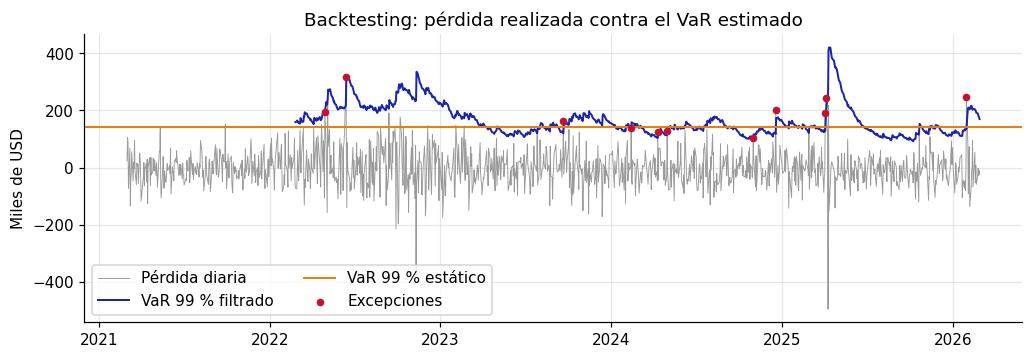

In [ ]:
fig, ax = plt.subplots()
ax.plot(loss.index, loss/1e3, color=GRIS, lw=0.6, label="Pérdida diaria")
ax.plot(VAR_FHS.index, VAR_FHS/1e3, color=AZUL, lw=1.3, label="VaR 99 % filtrado")
ax.axhline(var_n/1e3, color=NARANJA, lw=1.3, label="VaR 99 % estático")
ex = loss[excepciones["Histórico filtrado"].reindex(loss.index, fill_value=False)]
ax.scatter(ex.index, ex/1e3, s=16, color=ROJO, zorder=5, label="Excepciones")
ax.set_ylabel("Miles de USD"); ax.legend(ncol=2)
ax.set_title("Backtesting: pérdida realizada contra el VaR estimado")
plt.show()

### 3.2 Semáforo de Basilea

Sobre 250 ruedas y un VaR al 99 %:

| Zona | Excepciones | Multiplicador |
|---|---|---|
| Verde | 0 – 4 | 3,00 |
| Amarilla | 5 – 9 | 3,40 – 3,85 |
| Roja | 10 o más | 4,00 y revisión del modelo |

In [ ]:
def semaforo(k, N=250):
    esc = k * 250 / N               # proyeccion a 250 ruedas
    if esc <= 4:  return "Verde", 3.00
    if esc <= 9:  return "Amarilla", 3.40 + 0.09 * (esc - 5)
    return "Roja", 4.00

for k_, e in excepciones.items():
    zona, mult = semaforo(int(e.sum()), len(e))
    print(f"{k_:<20} proyectado a 250 ruedas: "
          f"{int(e.sum())*250/len(e):5.1f} excepciones → zona {zona} (m = {mult:.2f})")

Estático + normal    proyectado a 250 ruedas:   3.4 excepciones → zona Verde (m = 3.00)
EWMA + normal        proyectado a 250 ruedas:   5.2 excepciones → zona Amarilla (m = 3.42)
Histórico filtrado   proyectado a 250 ruedas:   2.7 excepciones → zona Verde (m = 3.00)


## Bloque 4 · Stress testing

$$\Delta V^{\mathrm{esc}} = V_t \sum_i w_i\, s_i$$

El VaR describe días normales. Los escenarios describen días que la muestra no contiene.

,Resultado USD
Lunes negro (1987),"-662,000"
Hipotético: correlaciones a 1,"-565,000"
Pánico por COVID (2020),"-517,000"
Shock de tasas (2022),"-384,000"
Quiebra de Lehman (2008),"-369,000"


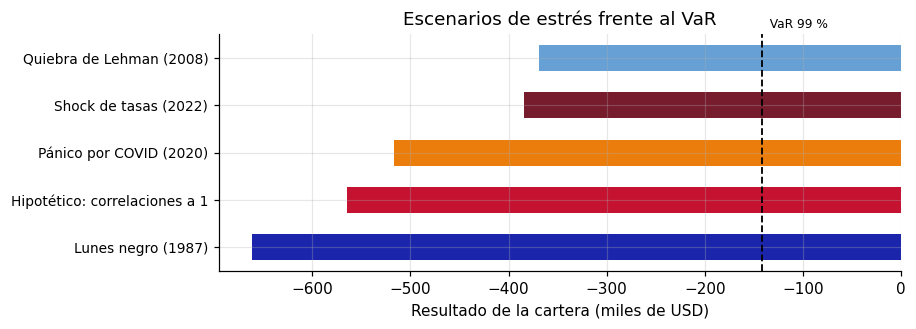


Peor escenario / VaR 99 % = 4.7 veces


In [ ]:
ESCENARIOS = {
    "Lunes negro (1987)":           {"SPY": -0.204, "TLT":  0.028, "GLD":  0.030, "EURUSD":  0.010},
    "Quiebra de Lehman (2008)":     {"SPY": -0.090, "TLT":  0.021, "GLD": -0.030, "EURUSD": -0.012},
    "Pánico por COVID (2020)":      {"SPY": -0.119, "TLT":  0.019, "GLD": -0.045, "EURUSD": -0.008},
    "Shock de tasas (2022)":        {"SPY": -0.040, "TLT": -0.055, "GLD": -0.022, "EURUSD": -0.015},
    "Hipotético: correlaciones a 1":{"SPY": -0.080, "TLT": -0.040, "GLD": -0.050, "EURUSD": -0.025},
}

res = {k: V0 * sum(PESOS[a] * v[a] for a in PESOS.index) for k, v in ESCENARIOS.items()}
st = pd.Series(res).sort_values()
display(st.to_frame("Resultado USD").style.format("{:,.0f}"))

fig, ax = plt.subplots(figsize=(8, 2.8))
ax.barh(range(len(st)), st.values/1e3,
        color=[AZUL, ROJO, NARANJA, VINO, CELESTE][:len(st)], height=0.55)
ax.set_yticks(range(len(st))); ax.set_yticklabels(st.index, fontsize=9)
ax.axvline(-var_n/1e3, color="black", ls="--", lw=1.2)
ax.text(-var_n/1e3, len(st)-0.3, "  VaR 99 %", fontsize=8, va="center")
ax.set_xlabel("Resultado de la cartera (miles de USD)")
ax.set_title("Escenarios de estrés frente al VaR")
plt.show()

print(f"\nPeor escenario / VaR 99 % = {abs(st.min())/var_n:.1f} veces")

### 4.2 Escenario inverso

En lugar de preguntar «cuánto puedo perder», el escenario inverso pregunta
**«qué tendría que pasar para que la pérdida alcance un umbral que no puedo absorber»**.
Es la formulación que mejor funciona en un comité de riesgos.

In [ ]:
PERDIDA_LIMITE = 1_000_000     # umbral que la entidad no podria absorber

# Escenario de minima norma que produce esa perdida (direccion de maxima verosimilitud
# bajo normalidad): s* proporcional a Sigma·w
direccion = S @ w
escala = -PERDIDA_LIMITE / (V0 * (w @ direccion))
s_inv = escala * direccion

print(f"Para perder {PERDIDA_LIMITE:,.0f} USD, el escenario más probable es:\n")
for a, s in zip(PESOS.index, s_inv):
    print(f"  {a:<7} {s:>8.2%}")
print(f"\nVerificación: {V0 * (w @ s_inv):,.0f} USD")
print(f"Ese escenario está a {np.sqrt(s_inv @ np.linalg.inv(S) @ s_inv):.1f} "
      f"desvíos de la media conjunta.")

Para perder 1,000,000 USD, el escenario más probable es:

  SPY      -12.88%
  TLT       -9.70%
  GLD       -9.32%
  EURUSD    -0.75%

Verificación: -1,000,000 USD
Ese escenario está a 16.0 desvíos de la media conjunta.


### ✏️ Consigna A — Escenarios propios

Diseñá **tres escenarios adicionales** relevantes para tu cartera del Trabajo Final:
uno histórico, uno hipotético y uno inverso. Justificá en dos líneas por qué cada uno
es plausible.

In [ ]:
# TU CÓDIGO ACÁ

## Bloque 5 · Informe de riesgo asistido por IA

### ✏️ Consigna B

Redactá la sección **«Validación»** del informe mensual dirigida a un comité no técnico,
con asistencia de IA, y documentá los tres controles.

**Plantilla de prompt**

```
# CONTEXTO
Cartera de 10 M USD: SPY 40 %, TLT 30 %, GLD 20 %, EURUSD 10 %.
VaR 99 % diario (histórico filtrado): ... USD
ES 97,5 %: ... USD
Backtesting sobre ... ruedas: ... excepciones
Kupiec p = ...   Christoffersen p = ...

# TAREA
Redacta la sección "Validación" del informe mensual,
dirigida a un comité de riesgos no técnico. Máximo 200 palabras.

# RESTRICCIONES
No afirmes que el modelo es correcto: los contrastes NO RECHAZAN,
que no es lo mismo. Declara el poder limitado de la prueba.

# VERIFICACIÓN
Enumera al final qué afirmaciones del texto requieren que yo
verifique un número contra el notebook.

# SUPUESTOS
Enumera los supuestos del método de estimación empleado.
```

> **El error más frecuente** que comete un modelo de lenguaje en este contexto es
> confundir «no se rechaza la hipótesis nula» con «el modelo es correcto». La restricción
> explícita del prompt lo previene.

In [ ]:
# Celda de resumen para pegar en el prompt
print(f"VaR 99 % (filtrado, último día): {VAR_FHS.iloc[-1]:,.0f} USD")
print(f"ES 97,5 % (histórico)          : {es_h:,.0f} USD")
e = excepciones["Histórico filtrado"]
lr_uc, p_uc = kupiec(e)
_, p_ind, _, p_cc = christoffersen(e)
print(f"Backtesting: {int(e.sum())} excepciones en {len(e)} ruedas")
print(f"  Kupiec         p = {p_uc:.3f}")
print(f"  Independencia  p = {p_ind:.3f}")
print(f"  Cond. conjunta p = {p_cc:.3f}")

VaR 99 % (filtrado, último día): 169,372 USD
ES 97,5 % (histórico)          : 164,767 USD
Backtesting: 11 excepciones en 1004 ruedas
  Kupiec         p = 0.764
  Independencia  p = 0.106
  Cond. conjunta p = 0.258


---

## Trabajo Final Integrador del Módulo 1

Elaborar un **informe de riesgo de mercado** sobre una cartera de al menos cinco
instrumentos, respaldado por un notebook reproducible. Extensión: 6 a 8 páginas más anexo.

**Debe incluir**

1. Construcción y saneamiento del panel, con las decisiones metodológicas documentadas.
2. Contraste de los hechos estilizados y su implicancia sobre la elección del método.
3. Estimación de volatilidad por al menos dos métodos, con justificación.
4. VaR y ES por al menos tres métodos, con descomposición por posición y por factor.
5. Backtesting completo: Kupiec, Christoffersen y semáforo de Basilea.
6. Al menos tres escenarios de estrés, uno de ellos inverso.
7. Sección explícita de supuestos y limitaciones.
8. Declaración del uso de IA con los tres controles documentados.

**Criterios de evaluación**

| Criterio | Peso |
|---|---|
| Corrección técnica | 35 % |
| Justificación metodológica | 25 % |
| Reproducibilidad del notebook | 20 % |
| Calidad de la comunicación | 10 % |
| Tratamiento de las limitaciones | 10 % |

---

**Lectura:** McNeil, Frey y Embrechts (2015), caps. 2 y 9; Christoffersen (2012), caps. 2, 8 y 13.